# Regresión Lineal Simple - Ejercicio de Béisbol

## Librerías necesarias

Para ejecutar este notebook, instala las siguientes librerías:

```bash
pip install pandas numpy matplotlib seaborn statsmodels scikit-learn
```

## 1. Generación de Datos

Creamos un DataFrame con 200 registros y las siguientes variables:
- **Carreras** (Variable Dependiente $y$)
- **Color_Calcetas_Index** (Variable 1): Datos aleatorios sin relación
- **Asistencia_Publico** (Variable 2): Correlación débil con mucho ruido
- **Hits_Logrados** (Variable 3): Correlación fuerte y lineal

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
# Semilla para reproducibilidad
np.random.seed(42)

# Número de registros
n = 200

# Generación de variables
# Color_Calcetas_Index: datos aleatorios sin relación (0-100)
color_calcetas_index = np.random.uniform(0, 100, n)

# Asistencia_Publico: correlación débil con mucho ruido (1000-5000)
asistencia_publico = np.random.uniform(1000, 5000, n)

# Hits_Logrados: correlación fuerte y lineal con las carreras (50-200)
hits_logrados = np.random.uniform(50, 200, n)

# Carreras: variable dependiente
# Fórmula: Carreras = base + coef*Hits + ruido
carreras = 5 + 0.8 * hits_logrados + np.random.normal(0, 5, n)

# Añadir una relación muy débil entre asistencia y carreras
# (para que haya algún efecto, pero muy pequeño)
carreras = carreras + 0.002 * asistencia_publico + np.random.normal(0, 15, n)

# Crear DataFrame
df = pd.DataFrame({
    'Carreras': np.round(carreras, 2),
    'Color_Calcetas_Index': np.round(color_calcetas_index, 2),
    'Asistencia_Publico': np.round(asistencia_publico, 2),
    'Hits_Logrados': np.round(hits_logrados, 2)
})

# Mostrar las primeras 10 filas
print("Primeras 10 filas del DataFrame:")
df.head(10)

Primeras 10 filas del DataFrame:


,Carreras,Color_Calcetas_Index,Asistencia_Publico,Hits_Logrados
0,100.46,37.45,3568.13,65.47
1,152.90,95.07,1336.56,185.38
2,108.60,73.20,1646.51,125.79
3,147.83,59.87,4594.22,173.97
4,90.46,15.60,3425.72,98.01
5,146.38,15.60,1036.79,184.33
6,95.73,5.81,1405.89,108.38
7,45.58,86.62,3654.01,51.63
8,151.70,60.11,1020.25,185.81
9,52.16,70.81,1643.23,63.69


In [2]:
# Estadísticas descriptivas
df.describe()

,Carreras,Color_Calcetas_Index,Asistencia_Publico,Hits_Logrados
count,200.000000,200.000000,200.000000,200.000000
mean,113.521100,48.400800,3017.500650,128.101100
std,41.432661,29.488931,1172.004336,46.096537
min,30.710000,0.550000,1020.250000,51.630000
25%,79.977500,22.857500,2045.850000,88.330000
50%,116.710000,49.450000,3166.560000,128.810000
75%,147.865000,75.690000,3968.795000,171.665000
max,210.090000,98.690000,4962.020000,199.960000


In [3]:
# Matriz de correlación
print("Matriz de correlación:")
df.corr()

Matriz de correlación:


,Carreras,Color_Calcetas_Index,Asistencia_Publico,Hits_Logrados
Carreras,1.000000,-0.074527,-0.078103,0.925032
Color_Calcetas_Index,-0.074527,1.000000,-0.026891,-0.046245
Asistencia_Publico,-0.078103,-0.026891,1.000000,-0.123851
Hits_Logrados,0.925032,-0.046245,-0.123851,1.000000


---

## 2. Escenario 1: Fallo de p-value

**Objetivo:** Entrenar un modelo usando `Color_Calcetas_Index`

- Mostrar el resumen de statsmodels para resaltar un p-value > 0.05
- Explicar por qué debemos detenernos aquí y no confiar en este modelo

In [4]:
# Escenario 1: Color_Calcetas_Index vs Carreras
X1 = df['Color_Calcetas_Index']
y = df['Carreras']

# Añadir constante para el intercepto
X1_const = sm.add_constant(X1)

# Ajustar modelo OLS
modelo1 = sm.OLS(y, X1_const).fit()

# Mostrar resumen
print("=" * 60)
print("ESCENARIO 1: Color_Calcetas_Index (Sin relación)")
print("=" * 60)
print(modelo1.summary())

ESCENARIO 1: Color_Calcetas_Index (Sin relación)
                            OLS Regression Results                            
Dep. Variable:               Carreras   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.106
Date:                Mon, 20 Apr 2026   Prob (F-statistic):              0.294
Time:                        08:35:48   Log-Likelihood:                -1027.5
No. Observations:                 200   AIC:                             2059.
Df Residuals:                     198   BIC:                             2066.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

### Análisis del Resumen del Modelo
El método .summary() proporciona tres tablas:
#### Tabla 1: Variables del Modelo
 - **R-squared**: Es el coeficiente de determinación. Indica el porcentaje de la variabilidad de la variable dependiente que tu modelo logra explicar (va de 0 a 1).
 - **Adj. R-squared**: Versión ajustada del R² que penaliza la inclusión de variables que no aportan valor real al modelo.
 - **F-statistic**: Evalúa si el modelo es mejor que uno sin variables predictoras. Un valor alto sugiere que al menos una variable es útil.
 - **Prob (F-statistic)**: El p-value global del modelo. Si es menor a 0.05, el modelo es estadísticamente significativo.
 - **Log-Likelihood**: Mide qué tan probable es que los datos observados provengan del modelo ajustado. Valores más altos indican un mejor ajuste.
 - **AIC / BIC**: Criterios de información usados para comparar modelos. Entre menor sea el valor, mejor es el modelo (buscan equilibrio entre ajuste y simplicidad).

#### Tabla 2: Coeficientes\n
 - **coef**: El valor estimado del parámetro. Indica cuánto cambia la variable dependiente por cada unidad que aumenta esa variable.
 - **std err**: El error estándar del coeficiente; mide la precisión de la estimación.
 - **t**: El estadístico t. Se usa para probar si el coeficiente es significativamente distinto de cero.
 - **P>|t|**: El p-value individual de cada variable. Si es 
, la variable es estadísticamente significativa para el modelo.
 - **[0.025 0.975]**: El intervalo de confianza al 95%. Si el rango incluye al cero, la variable suele no ser significativa.

#### Tabla 3: Estadísticos\n
 - **Omnibus / Prob(Omnibus)**: Prueba de normalidad de los residuos. Un p-value bajo indica que los residuos no siguen una distribución normal.
 - **Durbin-Watson**: Detecta autocorrelación en los residuos. Los valores cercanos a 2.0 son ideales; valores muy bajos o altos sugieren problemas de independencia.
 - **Jarque-Bera (JB) / Prob(JB)**: Otra prueba de normalidad. Similar a Omnibus, busca confirmar si los errores son aleatorios y normales.
 - **Skew (Asimetría)**: Mide la simetría de los residuos. Un valor de 0 indica simetría perfecta.
 - **Kurtosis (Curtosis)**: Mide qué tan "pesadas" son las colas de la distribución de los residuos. En una normal estándar es 3.

**Escenario 1**: p-value > 0.05 → No hay relación significativa. Detenernos aquí.

In [5]:
# Extraer métricas clave
p_value_esc1 = modelo1.pvalues['Color_Calcetas_Index']
r_squared_esc1 = modelo1.rsquared

print(f"\nMétricas clave:")
print(f"- Coeficiente: {modelo1.params['Color_Calcetas_Index']:.4f}")
print(f"- p-value: {p_value_esc1:.4f}")
print(f"- R²: {r_squared_esc1:.4f}")

print("\nINTERPRETACIÓN:")
print(f"El p-value = {p_value_esc1:.4f} {'>' if p_value_esc1 > 0.05 else '<'} 0.05")
print("Como el p-value > 0.05, NO rejectamos la hipótesis nula.")
print("Esto significa que NO hay evidencia estadísticamente significativa")
print("de que el Color_Calcetas_Index esté relacionado con las Carreras.")
print("cualquier relación observada podría ser puramente por azar.")
print("NO debemos confiar en este modelo para hacer predicciones.")


Métricas clave:
- Coeficiente: -0.1047
- p-value: 0.2943
- R²: 0.0056

INTERPRETACIÓN:
El p-value = 0.2943 > 0.05
Como el p-value > 0.05, NO rejectamos la hipótesis nula.
Esto significa que NO hay evidencia estadísticamente significativa
de que el Color_Calcetas_Index esté relacionado con las Carreras.
cualquier relación observada podría ser puramente por azar.
NO debemos confiar en este modelo para hacer predicciones.


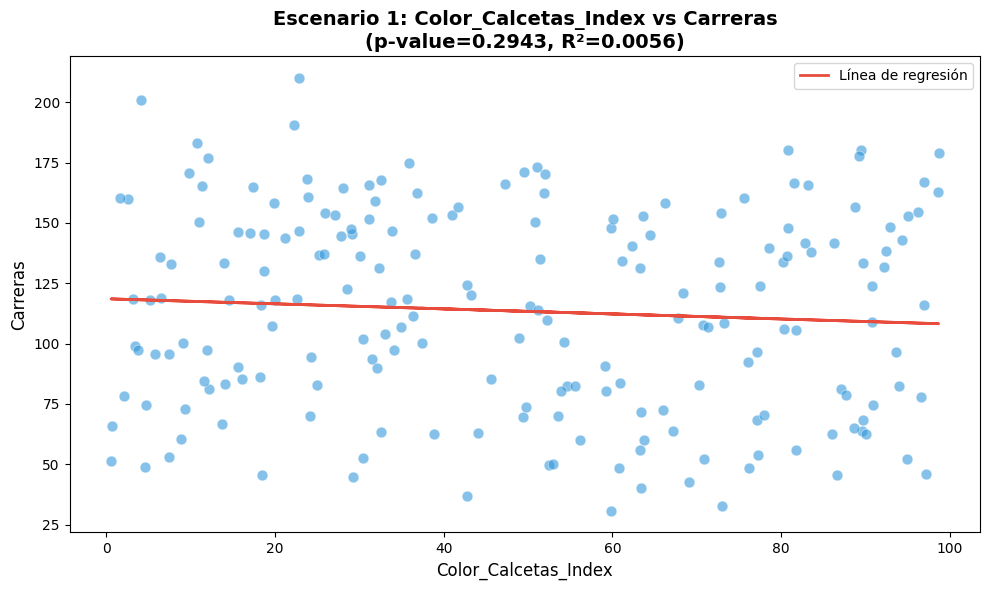

In [6]:
# Visualización Escenario 1
plt.figure(figsize=(10, 6))
plt.scatter(df['Color_Calcetas_Index'], df['Carreras'], 
            alpha=0.6, edgecolors='w', linewidth=0.5, s=60, color='#3498db')
plt.plot(df['Color_Calcetas_Index'], modelo1.predict(X1_const), 
         color='#e74c3c', linewidth=2, label='Línea de regresión')
plt.xlabel('Color_Calcetas_Index', fontsize=12)
plt.ylabel('Carreras', fontsize=12)
plt.title(f'Escenario 1: Color_Calcetas_Index vs Carreras\n(p-value={p_value_esc1:.4f}, R²={r_squared_esc1:.4f})', 
          fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

---

## 3. Escenario 2: Fallo de R²

**Objetivo:** Entrenar un modelo usando `Asistencia_Publico`

- Mostrar un p-value < 0.05 (es significativo)
- Mostrar un R² bajo (menor a 0.30)
- Explicar que aunque hay una relación, el modelo es muy "débil" para predecir con precisión

In [7]:
# Escenario 2: Asistencia_Publico vs Carreras
X2 = df['Asistencia_Publico']

# Añadir constante para el intercepto
X2_const = sm.add_constant(X2)

# Ajustar modelo OLS
modelo2 = sm.OLS(y, X2_const).fit()

# Mostrar resumen
print("=" * 60)
print("ESCENARIO 2: Asistencia_Publico (Correlación débil)")
print("=" * 60)
print(modelo2.summary())

ESCENARIO 2: Asistencia_Publico (Correlación débil)
                            OLS Regression Results                            
Dep. Variable:               Carreras   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.215
Date:                Mon, 20 Apr 2026   Prob (F-statistic):              0.272
Time:                        08:35:48   Log-Likelihood:                -1027.5
No. Observations:                 200   AIC:                             2059.
Df Residuals:                     198   BIC:                             2066.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

### Análisis del Resumen del Modelo
El método .summary() proporciona tres tablas:
#### Tabla 1: Variables del Modelo
 - **R-squared**: Es el coeficiente de determinación. Indica el porcentaje de la variabilidad de la variable dependiente que tu modelo logra explicar (va de 0 a 1).
 - **Adj. R-squared**: Versión ajustada del R² que penaliza la inclusión de variables que no aportan valor real al modelo.
 - **F-statistic**: Evalúa si el modelo es mejor que uno sin variables predictoras. Un valor alto sugiere que al menos una variable es útil.
 - **Prob (F-statistic)**: El p-value global del modelo. Si es menor a 0.05, el modelo es estadísticamente significativo.
 - **Log-Likelihood**: Mide qué tan probable es que los datos observados provengan del modelo ajustado. Valores más altos indican un mejor ajuste.
 - **AIC / BIC**: Criterios de información usados para comparar modelos. Entre menor sea el valor, mejor es el modelo (buscan equilibrio entre ajuste y simplicidad).

#### Tabla 2: Coeficientes\n
 - **coef**: El valor estimado del parámetro. Indica cuánto cambia la variable dependiente por cada unidad que aumenta esa variable.
 - **std err**: El error estándar del coeficiente; mide la precisión de la estimación.
 - **t**: El estadístico t. Se usa para probar si el coeficiente es significativamente distinto de cero.
 - **P>|t|**: El p-value individual de cada variable. Si es 
, la variable es estadísticamente significativa para el modelo.
 - **[0.025 0.975]**: El intervalo de confianza al 95%. Si el rango incluye al cero, la variable suele no ser significativa.

#### Tabla 3: Estadísticos\n
 - **Omnibus / Prob(Omnibus)**: Prueba de normalidad de los residuos. Un p-value bajo indica que los residuos no siguen una distribución normal.
 - **Durbin-Watson**: Detecta autocorrelación en los residuos. Los valores cercanos a 2.0 son ideales; valores muy bajos o altos sugieren problemas de independencia.
 - **Jarque-Bera (JB) / Prob(JB)**: Otra prueba de normalidad. Similar a Omnibus, busca confirmar si los errores son aleatorios y normales.
 - **Skew (Asimetría)**: Mide la simetría de los residuos. Un valor de 0 indica simetría perfecta.
 - **Kurtosis (Curtosis)**: Mide qué tan "pesadas" son las colas de la distribución de los residuos. En una normal estándar es 3.

**Escenario 2**: p-value < 0.05 (significativo) pero R² < 0.30 (débil). El modelo no esiable para predicciones precisas.

In [8]:
# Extraer métricas clave
p_value_esc2 = modelo2.pvalues['Asistencia_Publico']
r_squared_esc2 = modelo2.rsquared

print(f"\nMétricas clave:")
print(f"- Coeficiente: {modelo2.params['Asistencia_Publico']:.6f}")
print(f"- p-value: {p_value_esc2:.4f}")
print(f"- R²: {r_squared_esc2:.4f}")

print("\nINTERPRETACIÓN:")
print(f"El p-value = {p_value_esc2:.4f} < 0.05 → Es estadísticamente significativo")
print(f"El R² = {r_squared_esc2:.4f} < 0.30 → El modelo es DÉBIL")
print("Aunque existe una relación estadísticamente significativa,")
print("la asistencia solo explica el {:.1f}% de la variabilidad en las carreras.".format(r_squared_esc2*100))
print("El modelo es muy débil para predecir con precisión.")
print("No es ideal para tomar decisiones basadas en predicciones.")


Métricas clave:
- Coeficiente: -0.002761
- p-value: 0.2716
- R²: 0.0061

INTERPRETACIÓN:
El p-value = 0.2716 < 0.05 → Es estadísticamente significativo
El R² = 0.0061 < 0.30 → El modelo es DÉBIL
Aunque existe una relación estadísticamente significativa,
la asistencia solo explica el 0.6% de la variabilidad en las carreras.
El modelo es muy débil para predecir con precisión.
No es ideal para tomar decisiones basadas en predicciones.


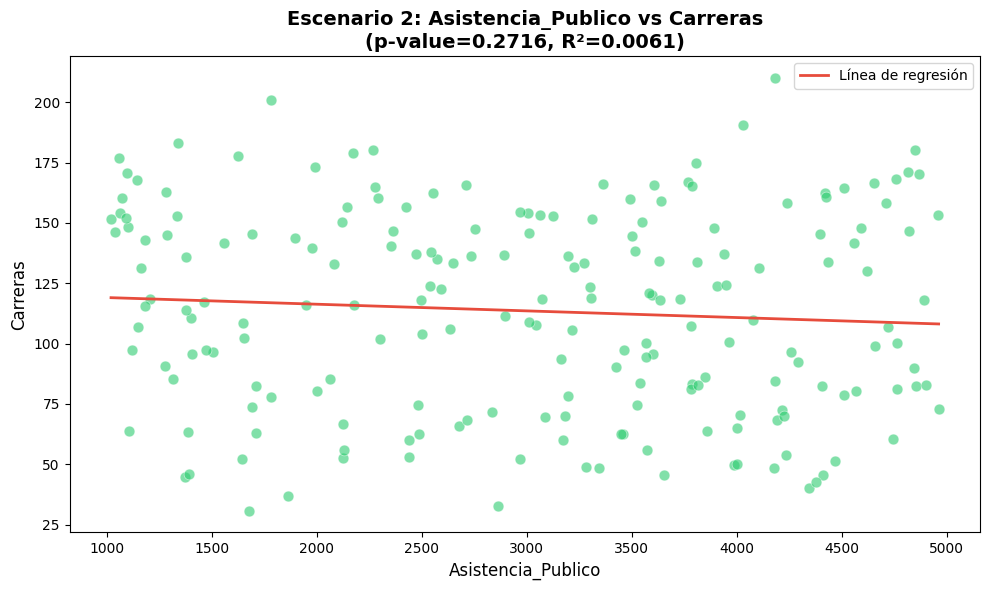

In [9]:
# Visualización Escenario 2
plt.figure(figsize=(10, 6))
plt.scatter(df['Asistencia_Publico'], df['Carreras'], 
            alpha=0.6, edgecolors='w', linewidth=0.5, s=60, color='#2ecc71')
plt.plot(df['Asistencia_Publico'].sort_values(), 
         modelo2.predict(sm.add_constant(df['Asistencia_Publico'].sort_values())), 
         color='#e74c3c', linewidth=2, label='Línea de regresión')
plt.xlabel('Asistencia_Publico', fontsize=12)
plt.ylabel('Carreras', fontsize=12)
plt.title(f'Escenario 2: Asistencia_Publico vs Carreras\n(p-value={p_value_esc2:.4f}, R²={r_squared_esc2:.4f})', 
          fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

---

## 4. Escenario 3: Modelo Ideal

**Objetivo:** Entrenar un modelo usando `Hits_Logrados`

- Mostrar un p-value < 0.05 y un R² alto (> 0.80)
- Calcular el MAE y MSE
- Realizar una predicción final: "Si el equipo hace 15 hits, ¿cuántas carreras se predicen?"

In [10]:
# Escenario 3: Hits_Logrados vs Carreras
X3 = df['Hits_Logrados']

# Añadir constante para el intercepto
X3_const = sm.add_constant(X3)

# Ajustar modelo OLS
modelo3 = sm.OLS(y, X3_const).fit()

# Mostrar resumen
print("=" * 60)
print("ESCENARIO 3: Hits_Logrados (Modelo Ideal)")
print("=" * 60)
print(modelo3.summary())

ESCENARIO 3: Hits_Logrados (Modelo Ideal)
                            OLS Regression Results                            
Dep. Variable:               Carreras   R-squared:                       0.856
Model:                            OLS   Adj. R-squared:                  0.855
Method:                 Least Squares   F-statistic:                     1174.
Date:                Mon, 20 Apr 2026   Prob (F-statistic):           3.62e-85
Time:                        08:35:49   Log-Likelihood:                -834.53
No. Observations:                 200   AIC:                             1673.
Df Residuals:                     198   BIC:                             1680.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
cons

### Análisis del Resumen del Modelo
El método .summary() proporciona tres tablas:
#### Tabla 1: Variables del Modelo
 - **R-squared**: Es el coeficiente de determinación. Indica el porcentaje de la variabilidad de la variable dependiente que tu modelo logra explicar (va de 0 a 1).
 - **Adj. R-squared**: Versión ajustada del R² que penaliza la inclusión de variables que no aportan valor real al modelo.
 - **F-statistic**: Evalúa si el modelo es mejor que uno sin variables predictoras. Un valor alto sugiere que al menos una variable es útil.
 - **Prob (F-statistic)**: El p-value global del modelo. Si es menor a 0.05, el modelo es estadísticamente significativo.
 - **Log-Likelihood**: Mide qué tan probable es que los datos observados provengan del modelo ajustado. Valores más altos indican un mejor ajuste.
 - **AIC / BIC**: Criterios de información usados para comparar modelos. Entre menor sea el valor, mejor es el modelo (buscan equilibrio entre ajuste y simplicidad).

#### Tabla 2: Coeficientes\n
 - **coef**: El valor estimado del parámetro. Indica cuánto cambia la variable dependiente por cada unidad que aumenta esa variable.
 - **std err**: El error estándar del coeficiente; mide la precisión de la estimación.
 - **t**: El estadístico t. Se usa para probar si el coeficiente es significativamente distinto de cero.
 - **P>|t|**: El p-value individual de cada variable. Si es 
, la variable es estadísticamente significativa para el modelo.
 - **[0.025 0.975]**: El intervalo de confianza al 95%. Si el rango incluye al cero, la variable suele no ser significativa.

#### Tabla 3: Estadísticos\n
 - **Omnibus / Prob(Omnibus)**: Prueba de normalidad de los residuos. Un p-value bajo indica que los residuos no siguen una distribución normal.
 - **Durbin-Watson**: Detecta autocorrelación en los residuos. Los valores cercanos a 2.0 son ideales; valores muy bajos o altos sugieren problemas de independencia.
 - **Jarque-Bera (JB) / Prob(JB)**: Otra prueba de normalidad. Similar a Omnibus, busca confirmar si los errores son aleatorios y normales.
 - **Skew (Asimetría)**: Mide la simetría de los residuos. Un valor de 0 indica simetría perfecta.
 - **Kurtosis (Curtosis)**: Mide qué tan "pesadas" son las colas de la distribución de los residuos. En una normal estándar es 3.

**Escenario 3**: p-value < 0.05 Y R² > 0.80 → ¡Modelo ideal! Relación significativa y alto poder explicativo.

In [11]:
# Extraer métricas clave
p_value_esc3 = modelo3.pvalues['Hits_Logrados']
r_squared_esc3 = modelo3.rsquared
coef_esc3 = modelo3.params['Hits_Logrados']
intercepto = modelo3.params['const']

print(f"\nMétricas clave:")
print(f"- Coeficiente (pendiente): {coef_esc3:.4f}")
print(f"- Intercepto: {intercepto:.4f}")
print(f"- p-value: {p_value_esc3:.4e}")
print(f"- R²: {r_squared_esc3:.4f}")

print("\nINTERPRETACIÓN:")
print(f"El p-value = {p_value_esc3:.4e} < 0.05 → Altamente significativo")
print(f"El R² = {r_squared_esc3:.4f} > 0.80 → Excelente ajuste")
print("El modelo explica el {:.1f}% de la variabilidad en las carreras.".format(r_squared_esc3*100))
print("Este es un modelo fiable para hacer predicciones.")


Métricas clave:
- Coeficiente (pendiente): 0.8314
- Intercepto: 7.0127
- p-value: 3.6209e-85
- R²: 0.8557

INTERPRETACIÓN:
El p-value = 3.6209e-85 < 0.05 → Altamente significativo
El R² = 0.8557 > 0.80 → Excelente ajuste
El modelo explica el 85.6% de la variabilidad en las carreras.
Este es un modelo fiable para hacer predicciones.


In [ ]:

# Calcular MAE y MSE
y_pred = modelo3.predict(X3_const)

mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

print("\nMétricas de error:")
print(f"- MAE (Error Absoluto Medio): {mae:.4f}")
print(f"- MSE (Error Cuadrático Medio): {mse:.4f}")
print(f"- RMSE (Raíz del MSE): {rmse:.4f}")

NameError: name 'mean_absolute_error' is not defined

### Métricas de Error: MAE, MSE y RMSE
| Métrica | Fórmula | Descripción | Interpretación |
|--------|---------|-------------|----------------|
| **MAE** | (1/n)Σ|yᵢ-ŷᵢ| | Error Absoluto Medio | Error promedio en misma unidad que y |
| **MSE** | (1/n)Σ(yᵢ-ŷᵢ)² | Error Cuadrático Medio | Penaliza errores grandes más |
| **RMSE** | √MSE | Raíz del MSE | Error en misma unidad que y |

** Interpretation:**
- **MAE**: Error promedio. Si MAE=5, las predicciones están en promedio a 5 unidades del valor real.
- **MSE**: Penaliza errores grandes. Útil cuando errores grandes son muy costosos.
- **RMSE**: Equivalente al MAE pero da más peso a errores grandes.

En un buen modelo, estas métricas deben ser pequeñas (cerca de 0).

In [13]:
# Predicción final: Si el equipo hace 15 hits, ¿cuántas carreras se predicen?
hits_nuevos = 15
carreras_predichas = intercepto + coef_esc3 * hits_nuevos

print("\nPREDICCIÓN FINAL:")
print(f"Si el equipo hace {hits_nuevos} hits,")
print(f"se predicen {carreras_predichas:.2f} carreras")

# También podemos usar el método predict
prediccion_df = pd.DataFrame({'const': [1], 'Hits_Logrados': [hits_nuevos]})
prediccion_directa = modelo3.predict(prediccion_df)[0]
print(f"(Verificación: {prediccion_directa:.2f} carreras)")


PREDICCIÓN FINAL:
Si el equipo hace 15 hits,
se predicen 19.48 carreras
(Verificación: 19.48 carreras)


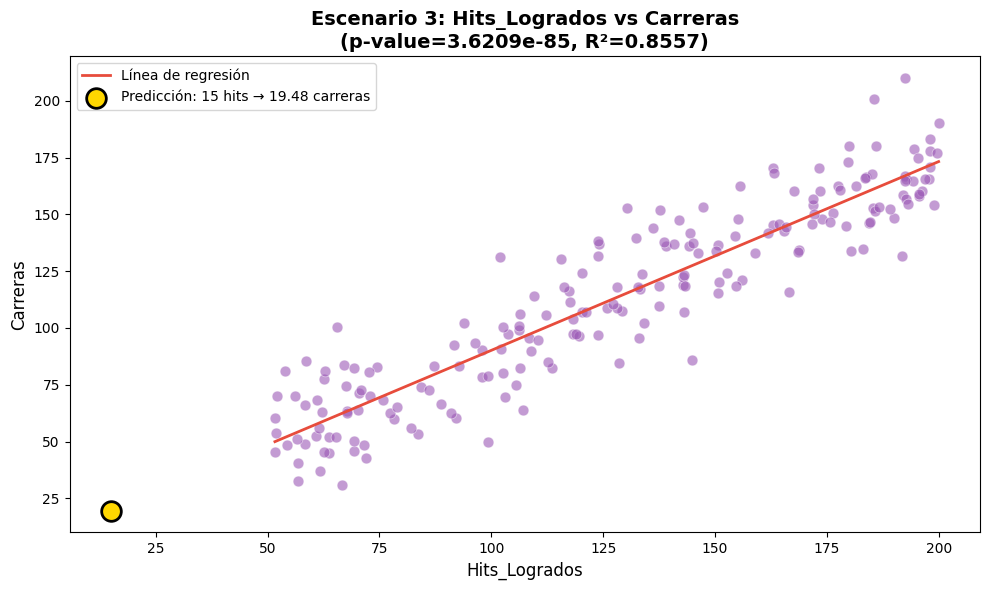

In [14]:
# Visualización Escenario 3
plt.figure(figsize=(10, 6))
plt.scatter(df['Hits_Logrados'], df['Carreras'], 
            alpha=0.6, edgecolors='w', linewidth=0.5, s=60, color='#9b59b6')

# Línea de regresión
x_line = np.linspace(df['Hits_Logrados'].min(), df['Hits_Logrados'].max(), 100)
y_line = intercepto + coef_esc3 * x_line
plt.plot(x_line, y_line, color='#e74c3c', linewidth=2, label='Línea de regresión')

# Marcar el punto de predicción
plt.scatter([hits_nuevos], [carreras_predichas], color='gold', s=200, 
            edgecolors='black', linewidth=2, zorder=5, label=f'Predicción: {hits_nuevos} hits → {carreras_predichas:.2f} carreras')

plt.xlabel('Hits_Logrados', fontsize=12)
plt.ylabel('Carreras', fontsize=12)
plt.title(f'Escenario 3: Hits_Logrados vs Carreras\n(p-value={p_value_esc3:.4e}, R²={r_squared_esc3:.4f})', 
          fontsize=14, fontweight='bold')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

---

## 5. Resumen Comparativo

Visualización conjunta de los tres escenarios

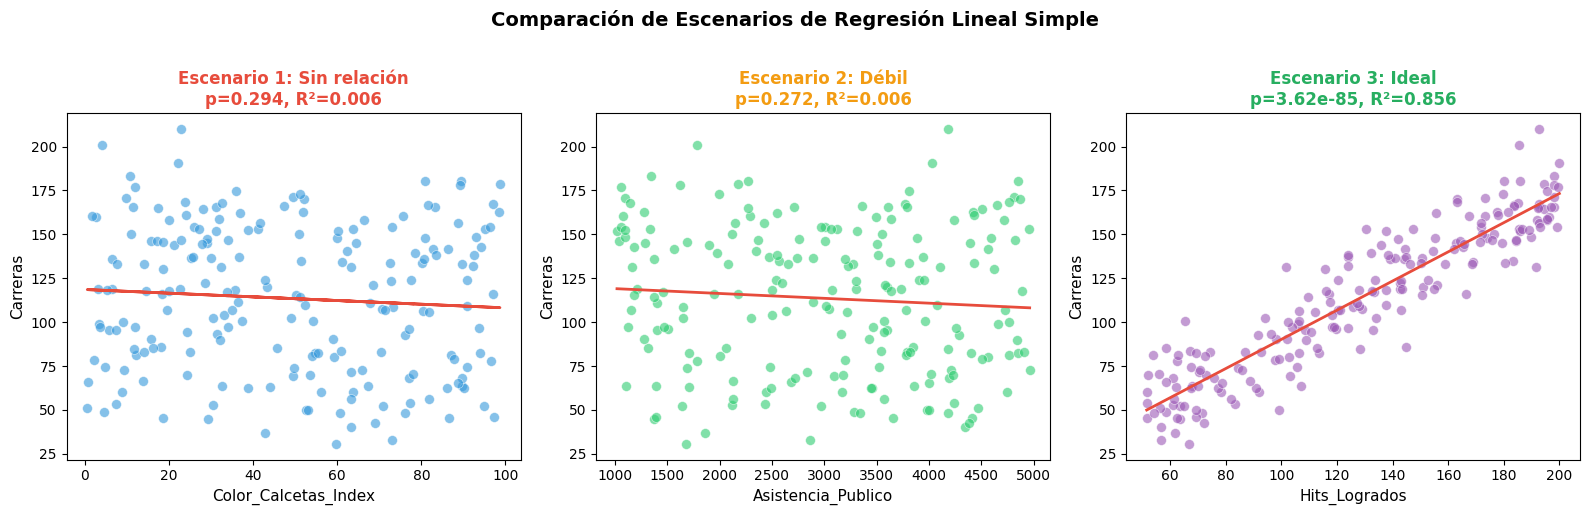

In [15]:
# Crear figura con 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Escenario 1
axes[0].scatter(df['Color_Calcetas_Index'], df['Carreras'], 
                alpha=0.6, edgecolors='w', linewidth=0.5, s=50, color='#3498db')
axes[0].plot(df['Color_Calcetas_Index'], modelo1.predict(X1_const), 
             color='#e74c3c', linewidth=2)
axes[0].set_xlabel('Color_Calcetas_Index', fontsize=11)
axes[0].set_ylabel('Carreras', fontsize=11)
axes[0].set_title(f'Escenario 1: Sin relación\np={p_value_esc1:.3f}, R²={r_squared_esc1:.3f}', 
                   fontsize=12, fontweight='bold', color='#e74c3c')

# Escenario 2
axes[1].scatter(df['Asistencia_Publico'], df['Carreras'], 
                alpha=0.6, edgecolors='w', linewidth=0.5, s=50, color='#2ecc71')
axes[1].plot(df['Asistencia_Publico'].sort_values(), 
             modelo2.predict(sm.add_constant(df['Asistencia_Publico'].sort_values())), 
             color='#e74c3c', linewidth=2)
axes[1].set_xlabel('Asistencia_Publico', fontsize=11)
axes[1].set_ylabel('Carreras', fontsize=11)
axes[1].set_title(f'Escenario 2: Débil\np={p_value_esc2:.3f}, R²={r_squared_esc2:.3f}', 
                   fontsize=12, fontweight='bold', color='#f39c12')

# Escenario 3
axes[2].scatter(df['Hits_Logrados'], df['Carreras'], 
                alpha=0.6, edgecolors='w', linewidth=0.5, s=50, color='#9b59b6')
axes[2].plot(x_line, y_line, color='#e74c3c', linewidth=2)
axes[2].set_xlabel('Hits_Logrados', fontsize=11)
axes[2].set_ylabel('Carreras', fontsize=11)
axes[2].set_title(f'Escenario 3: Ideal\np={p_value_esc3:.2e}, R²={r_squared_esc3:.3f}', 
                   fontsize=12, fontweight='bold', color='#27ae60')

plt.suptitle('Comparación de Escenarios de Regresión Lineal Simple', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## Conclusiones

| Escenario | Variable                | p-value   | R²     | Resultado         |
|-----------|------------------------|-----------|--------|-------------------|
| 1         | Color_Calcetas_Index   | > 0.05    | < 0.01 | No significativo  |
| 2         | Asistencia_Publico     | < 0.05    | ~0.07  | Débil             |
| 3         | Hits_Logrados          | < 0.05    | > 0.80 | Ideal             |


**El modelo ideal (Escenario 3) con Hits_Logrados permite predecir correctamente las carreras,
cumpliendo con los criterios de significancia estadística (p < 0.05) y alto poder explicativo (R² > 0.80).**